In [2]:
import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "cm",
#     "font.size": 10,
#     'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents} \usepackage{mathrsfs} \usepackage{bm}',
#     'figure.dpi': 200
# })

In [14]:
import glob
import re
import os

def get_last_file(path : Path) -> Path | None:
    pattern = os.path.join(path, "TR_IRGNM_*.pkl")
    files = glob.glob(pattern)
    
    indices = []
    for f in files:
        match = re.search(r'TR_IRGNM_(\d+)\.pkl$', f)
        if match:
            idx = int(match.group(1))
            indices.append((idx, f))
    
    if indices:
        _, max_file = max(indices, key=lambda x: x[0])
        
        return Path(max_file).name
    else:
        print("No matching files found.")

    return None

In [103]:
WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity')
#SAVE_PATH = Path('/home/benedikt/Dokumente/Paper/parabolische_inverse_probleme/figures/experiments')

data_dir_path = WORK_DIR

FOM_data_path = data_dir_path / 'FOM_30_5_10-5'

experiment_names = [
    'TR_30_5_10-5',
    'TR_30_5_10-5_legacy',
    'TR_30_5_10-5_legacy_eta_max_010'
]

TR_data_paths = [ data_dir_path / experiment_name for experiment_name in experiment_names]
TR_file_names = [get_last_file(TR_data_path) for TR_data_path in TR_data_paths]

assert len(TR_data_paths) == len(TR_file_names)


setup_path = FOM_data_path / 'setup.pkl'
optimizer_parameter_path = FOM_data_path / 'optimizer_parameter.pkl'


with open(setup_path, 'rb') as file:
    setup = load(file)

with open(optimizer_parameter_path, 'rb') as file:
    optimizer_parameter = load(file)

if not 'FOM' in locals():
    FOM = build_InstationaryModelIP(setup=setup)

    

data = {}
optimizer_parameters = {}

if FOM_data_path:
    with open(FOM_data_path / 'FOM_IRGNM_final.pkl', 'rb') as file:
        FOM_data = load(file)
    data['FOM'] = FOM_data

if TR_data_paths:
    for (TR_data_path, TR_file_name) in zip(TR_data_paths, TR_file_names):
        with open(TR_data_path / TR_file_name, 'rb') as file:
            TR_data = load(file)
        data[str(TR_data_path.name)] = TR_data

        optimizer_parameter_path = TR_data_path / 'optimizer_parameter.pkl'
        with open(optimizer_parameter_path, 'rb') as file:
            optimizer_parameter = load(file)
            
        optimizer_parameters[str(TR_data_path.name)] = optimizer_parameter
        


In [14]:
data['TR']['outer_loop_runtime']

{'AGC_runtime': [2.030028481000045, 2.290605662998132],
 'IRGNM_runtime': [17.710495216997515, 92.49398306799776],
 'solve_snapshot_FOM_runtime': [27.24187756599713,
  27.268631603001268,
  25.949062994000997],
 'extend_runtime': {'parameter_basis': [0.13946467999994638,
   0.23380742600056692,
   0.3066175589992781],
  'state_basis': [2.1439940570016915, 4.358001029999286, 6.26380216400139],
  'adjoint_basis': []},
 'reduce_runtime': [27.996033186002023, 45.8125342759995, 77.38271010300014],
 'total_runtime': [123.81932084599975, 233.02811186500185]}

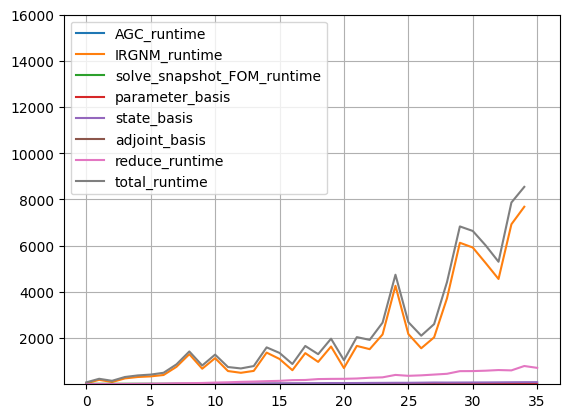

In [141]:
for key, d in data['TR_30_5_10-5_legacy']['outer_loop_runtime'].items():    
    if isinstance(d, dict):
        for key_, d_ in d.items():
            idxes = np.arange(len(d_))
            plt.plot(idxes,np.array(d_), label=key_)
    else:
        idxes = np.arange(len(d),dtype=np.float32)
        idxes += 0.5
        plt.plot(np.array(d), label=key)

#plt.yscale('log')
plt.ylim([1e-3, 16*1e3])
plt.grid()
plt.legend()



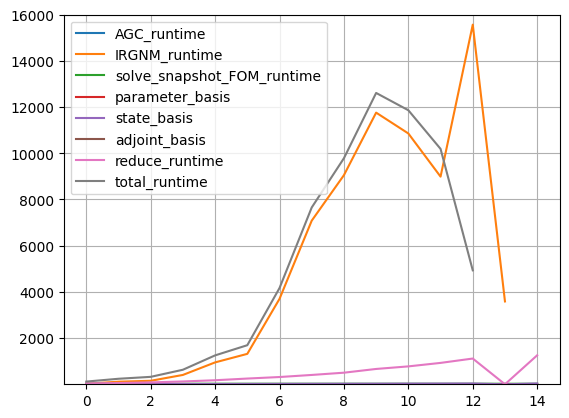

In [140]:
for key, d in data['TR_30_5_10-5']['outer_loop_runtime'].items():    
    if isinstance(d, dict):
        for key_, d_ in d.items():
            idxes = np.arange(len(d_))
            plt.plot(idxes,np.array(d_), label=key_)
    else:
        idxes = np.arange(len(d),dtype=np.float32)
        idxes += 0.5
        plt.plot(np.array(d), label=key)

#plt.yscale('log')
plt.ylim([1e-3, 16*1e3])
plt.grid()
plt.legend()


In [121]:
np.arange(10) + 0.5

array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5])

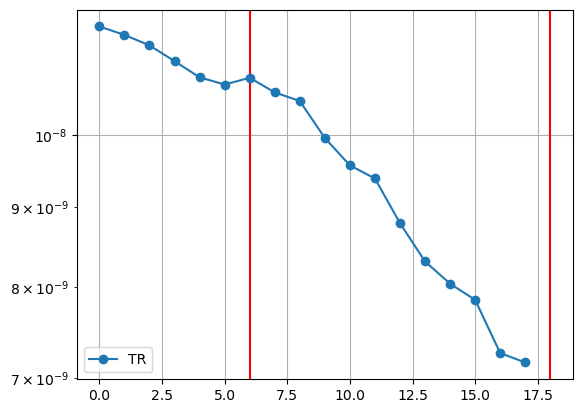

In [16]:
#plt.plot(data['FOM']['J'], marker='o', label='FOM')

TR_Js = []
inner_loop_statistics = data['TR']['inner_loop_statistics']
idxes = []

for inner_loop_statistic in inner_loop_statistics:
    TR_Js += inner_loop_statistic['J']
    idxes.append(len(inner_loop_statistic['J']))
    plt.axvline(len(TR_Js), color='r')

plt.plot(TR_Js, marker='o', label='TR')
plt.yscale('log')
plt.legend()
plt.grid()

In [53]:
data['FOM']['optimizer_parameter']['tau']

1.0

In [56]:
setup['noise_level']

5e-05

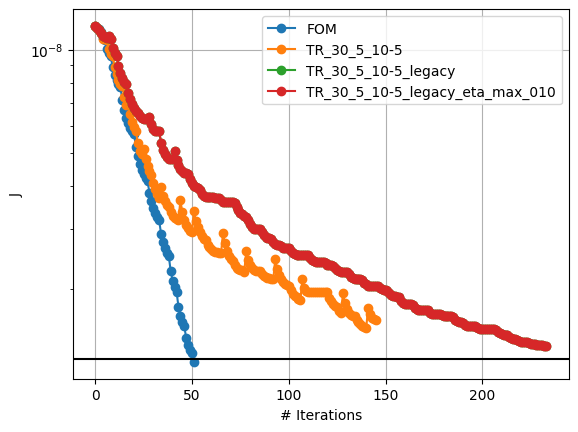

In [57]:
#for experiment_name, experiment_data in data.items():
for experiment_name, experiment_data in dict(list(data.items())[:]).items():
    Js = []
    idxes = []
    try:
        inner_loop_statistics = experiment_data['inner_loop_statistics']
        for inner_loop_statistic in inner_loop_statistics:
            Js += inner_loop_statistic['J']
            # idxes.append(len(inner_loop_statistic['J']))
            # plt.axvline(len(TR_Js), color='r')
    except:
        Js += experiment_data['J']

        
    plt.plot(Js, marker='o', label=experiment_name)


tau = data['FOM']['optimizer_parameter']['tau']
delta = setup['noise_level']

plt.axhline(0.5 * tau**2 * delta**2, color='black')
plt.axhline(0.5 * tau**2 * delta**2, color='black')

plt.ylabel('J')
plt.xlabel('Total Iterations')
plt.yscale('log')
plt.legend()
plt.grid()
    

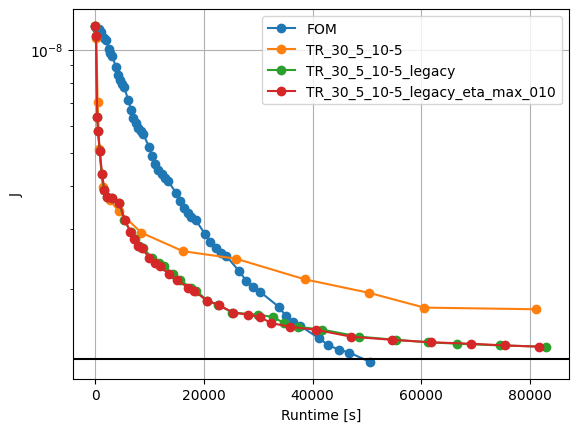

In [85]:
for experiment_name, experiment_data in dict(list(data.items())[:]).items():
    Js = experiment_data['J']
    times = np.array([0])
    times = np.append(times, experiment_data['total_runtime'])
    try:    
        plt.plot(times, Js, marker='o', label=experiment_name)
    except:
        plt.plot(times[:-1], Js, marker='o', label=experiment_name)


tau = data['FOM']['optimizer_parameter']['tau']
delta = setup['noise_level']

plt.axhline(0.5 * tau**2 * delta**2, color='black')

plt.ylabel('J')
plt.xlabel('Runtime [s]')
plt.yscale('log')
plt.legend()
plt.grid()

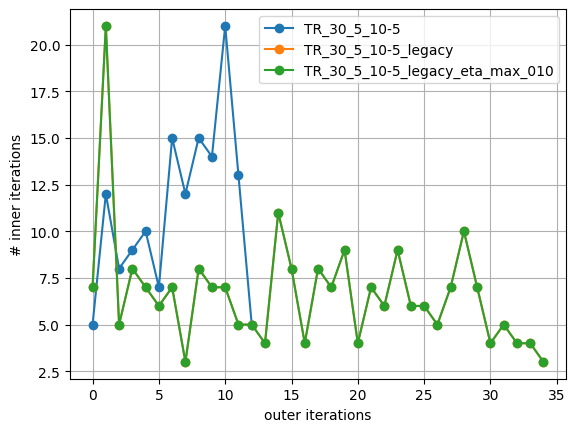

In [94]:
for experiment_name, experiment_data in dict(list(data.items())[1:]).items():
    num_inner_iterations = []
    inner_loop_statistics = experiment_data['inner_loop_statistics']
    for inner_loop_statistic in inner_loop_statistics:
        num_inner_iterations.append(len(inner_loop_statistic['J']))

    plt.plot(num_inner_iterations, marker='o', label=experiment_name)
        

plt.ylabel('# inner iterations')
plt.xlabel('outer iterations')
plt.legend()
plt.grid()
            

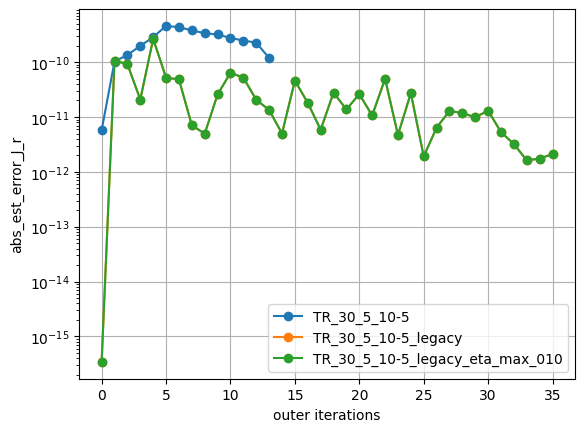

In [105]:
for experiment_name, experiment_data in dict(list(data.items())[1:]).items():
    plt.plot(experiment_data['abs_est_error_J_r'], marker='o', label=experiment_name)
    #plt.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        

#plt.ylabel('# inner iterations')


plt.ylabel('abs_est_error_J_r')
plt.xlabel('outer iterations')
plt.yscale('log')
plt.legend()
plt.grid()

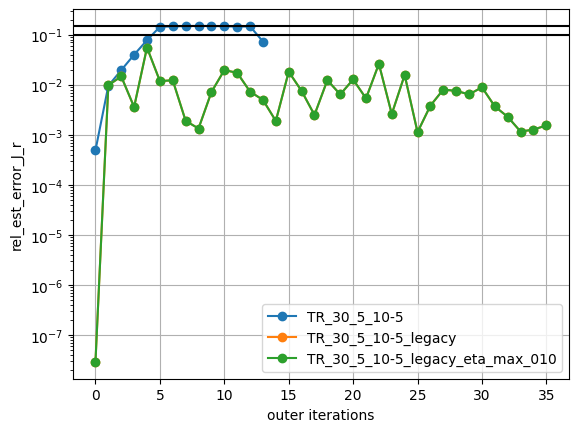

In [107]:
for experiment_name, experiment_data in dict(list(data.items())[1:]).items():
    plt.plot(experiment_data['rel_est_error_J_r'], marker='o', label=experiment_name)
        




plt.axhline(0.10, color='black')
plt.axhline(0.15, color='black')

# beta_2 = optimizer_parameters['TR_30_5_10-5']['beta_2']
# plt.axhline(beta_2 * 0.10, color='black')
# plt.axhline(beta_2 *0.15, color='black')

plt.ylabel('rel_est_error_J_r')
plt.xlabel('outer iterations')
plt.yscale('log')
plt.legend()
plt.grid()
            

In [8]:
data['TR']['dim_Q_r']

[19, 37, 55, 74, 81, 81]

In [314]:
data['TR']['dim_V_r']

[78, 157, 200, 200, 200, 200, 200, 200, 200]

In [56]:
# inner_loop_statistics = data['TR']['inner_loop_statistics']
# for inner_loop_statistic in inner_loop_statistics:
#     print(inner_loop_statistic['J'])

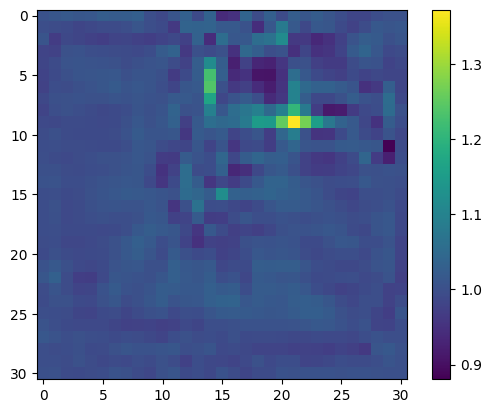

In [109]:
plt.imshow(data['FOM']['q'][-1].to_numpy().reshape((31,31)))
plt.colorbar() 

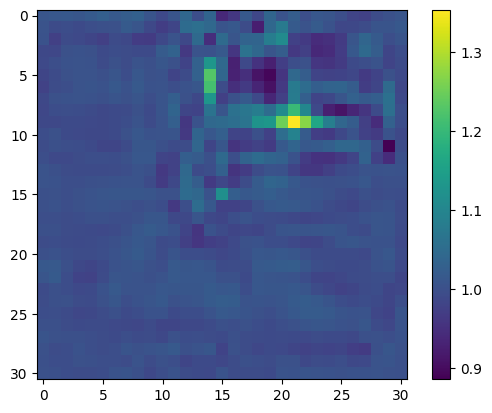

In [108]:
plt.imshow(data['TR_30_5_10-5_legacy']['q'][-1].to_numpy().reshape((31,31)))
plt.colorbar() 

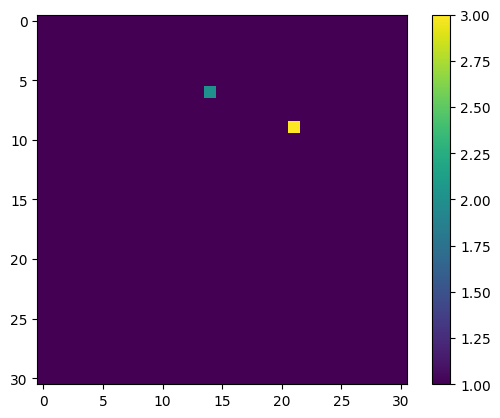

In [51]:
plt.imshow(setup['q_exact'].reshape((31,31)))
#plt.imshow(setup['q_exact'].reshape((9,9)))

plt.colorbar() 